# Sistema de Processamento Visual — Contador de Comprimidos
**Equipe:** Os Laplacianos  
**Integrantes:** Matheus Foresto Moselli · Marcos Vinicius Medeiros da Silva · Karl Eloy Marques Henrique  
**Disciplina:** MCZA018 – Processamento Digital de Imagens  
**Data de Publicação:** 30/03/2026

---
## 1. Imports

In [143]:
# Equipe: Os Laplacianos
# Integrantes: Matheus Foresto Moselli, Marcos Vinicius Medeiros da Silva, Karl Eloy Marques Henrique
# Data: 30/03/2026  |  Programa: spv_contador_comprimidos.ipynb
# Descrição: SPV para contagem automática de comprimidos via processamento de imagem.
# Execução: jupyter notebook spv_contador_comprimidos.ipynb

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Definindo quantidade de comprimidos por imagem para etapas posteriores
ground_truth = {
    'n1.jpeg': 6,
    'n2.jpeg': 6,
    'n3.jpeg': 4,
    'n4.jpeg': 6,
}

## 2. Parâmetros Globais

In [144]:
# Pré-processamento
KERNEL_BLUR        = 31     # Tamanho do filtro Gaussiano
CLAHE_CLIP         = 2.0    # Limite de contraste do CLAHE
CLAHE_GRID         = (8, 8) # Grade de tiles do CLAHE

# Morfologia
KERNEL_MORPH       = 21     # Mantido igual ao código original

# Filtragem de regiões
AREA_MIN           = 1500   # Área mínima para considerar como comprimido (px²)
CIRCULARIDADE_MIN  = 0.6    # Circularidade mínima (0=qualquer, 1=círculo perfeito)

# Watershed
KERNEL_WATERSHED = 3
DIST_TRANSFORMATION_MASK_SIZE = 0
PERCENT_MAX_DISTANCE = 0.1

## 3. Fluxo de processamento

### [A] Pré-processamento
*Conceitos aplicados: **Processamento de Cores** e **Histograma / Equalização***

In [145]:
def preprocessar(img):
    """
    Aplica processamento de cores e equalização de histograma.

    Etapas:
        1. BGR → LAB  : separa luminância (L) de crominância (a, b),
                        tornando o contraste independente da cor.
        2. CLAHE      : equalização adaptativa com limite de contraste no
                        canal L — realça bordas de comprimidos sem
                        amplificar ruídos de fundo.
        3. Gaussiano  : suaviza ruídos de textura antes da binarização.

    Parâmetros:
        img : imagem BGR lida pelo OpenCV

    Retorna:
        blur     : imagem em tons de cinza suavizada (entrada para binarizar)
        img_rgb  : imagem original em RGB (para exibição via matplotlib)
    """
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Obtendo o canal L
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    canal_l = lab[:, :, 0]

    # Aplicando CLAHE (Contrast Limited Adaptive Histogram Equalization) no canal L
    clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=CLAHE_GRID)
    canal_l_eq = clahe.apply(canal_l)
    lab[:, :, 0] = canal_l_eq

    # Converter de volta para BGR e extrair cinza equalizado
    img_eq = cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)
    gray   = cv2.cvtColor(img_eq, cv2.COLOR_BGR2GRAY)

    # Filtragem: Gaussiano
    blur = cv2.GaussianBlur(gray, (KERNEL_BLUR, KERNEL_BLUR), 0)

    return blur, img_rgb

### [B] Binarização e Morfologia
*Conceitos aplicados: **Operadores Morfológicos** e binarização por limiar de Otsu*

In [146]:
def binarizar(blur):
    """
    Binariza a imagem e aplica operadores morfológicos.

    Etapas:
        1. Otsu      : limiar automático — separa comprimidos do fundo
                       sem parâmetro manual, adaptando-se a diferentes
                       iluminações.
        2. MORPH_OPEN: erosão seguida de dilatação com kernel 15×15 —
                       remove ruídos menores que o kernel e suaviza
                       bordas dos comprimidos.

    Parâmetros:
        blur : imagem em tons de cinza suavizada (saída de preprocessar)

    Retorna:
        opening : máscara binária com regiões de comprimidos
    """
    # Binarização Otsu
    _, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Operadores Morfológicos
    kernel  = np.ones((KERNEL_MORPH, KERNEL_MORPH), np.uint8)

    # Remove mancas brancas pequenas
    opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

    # Remove buracos
    closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel)

    return closing

### [C] Segmentação com Watershed
*Conceito aplicado: **Segmentação — Watershed***

In [147]:
def aplicar_watershed(img_binarizada, img_bgr):
    """
    Aplica o algoritmo Watershed para separar comprimidos sobrepostos.

    Etapas:
        1. Transformada de distância → picos = centros dos comprimidos
        2. Threshold nos picos → marcadores "frente certa" (objeto)
        3. Dilatação da máscara → marcadores "fundo certo"
        4. Região desconhecida = fundo_certo − frente_certa
        5. cv2.watershed() propaga os marcadores e traça bordas (−1)

    Parâmetros:
        img_binarizada  : máscara binária pós-morfologia (saída de binarizar)
        img_bgr  : imagem BGR original (necessária para cv2.watershed)

    Retorna:
        markers  : mapa de rótulos; cada comprimido recebe um ID único;
                   bordas Watershed marcadas com −1
    """
    kernel     = np.ones((KERNEL_WATERSHED, KERNEL_WATERSHED), np.uint8)
    fundo_certo = cv2.dilate(img_binarizada, kernel, iterations=3)

    dist_transform = cv2.distanceTransform(
        img_binarizada,
        cv2.DIST_L2,
        DIST_TRANSFORMATION_MASK_SIZE
    )

    _, frente_certa = cv2.threshold(
        dist_transform,
        PERCENT_MAX_DISTANCE * dist_transform.max(),
        255,
        0
    )

    frente_certa = np.uint8(frente_certa)

    desconhecido = cv2.subtract(fundo_certo, frente_certa)

    _, markers = cv2.connectedComponents(frente_certa)
    markers = markers + 1
    markers[desconhecido == 255] = 0

    markers = cv2.watershed(img_bgr, markers)
    # markers == -1 → borda entre dois objetos
    # markers == 1  → fundo
    # markers >= 2  → cada comprimido

    return markers

### [D] Detecção, Filtragem e Classificação

In [148]:
def detectar(markers, img_rgb, nome_arquivo=""):
    """
    Extrai contornos do mapa de rótulos do Watershed e filtra por
    área e circularidade — mantendo a lógica original do colega.

    Classificação:
        circularidade > 0.85 → "Redonda"
        circularidade > 0.60 → "Elipse"

    Parâmetros:
        markers      : mapa de rótulos do Watershed
        img_rgb      : imagem RGB para desenhar os resultados
        nome_arquivo : usado no título do plot

    Retorna:
        result : imagem RGB anotada com contornos e rótulos
        count  : número de comprimidos detectados
    """
    result = img_rgb.copy()
    count  = 0

    for region_id in np.unique(markers):
        if region_id <= 1:   # 1 = fundo, -1 = borda Watershed
            continue

        # Máscara isolada para esse comprimido
        mask_region = np.uint8(markers == region_id) * 255
        contours, _ = cv2.findContours(
            mask_region, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )
        if not contours:
            continue
        cnt = contours[0]

        area = cv2.contourArea(cnt)
        if area <= AREA_MIN:
            continue

        perimeter    = cv2.arcLength(cnt, True)
        circularity  = (4 * np.pi * area / (perimeter ** 2)
                        if perimeter > 0 else 0)

        if circularity <= CIRCULARIDADE_MIN:
            continue

        count += 1
        tipo   = "Redonda" if circularity > 0.85 else "Elipse"

        cv2.drawContours(result, [cnt], -1, (0, 255, 0), 5)

        M  = cv2.moments(cnt)
        cX = int(M["m10"] / M["m00"]) if M["m00"] != 0 else 0
        cY = int(M["m01"] / M["m00"]) if M["m00"] != 0 else 0

        label = f"#{count}: {tipo}"
        cv2.putText(
            result,
            label,
            (cX + 50, cY),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.2,
            (0, 255, 0),
            3
        )

    return result, count

## 4. Função Principal de Exibição

In [149]:
def exibir_deteccao_comprimidos(caminho_imagem,
                                area_min=AREA_MIN,
                                circularidade_min=CIRCULARIDADE_MIN,
                                dose_esperada=0):
    """
    Extrai os comprimidos de uma imagem e exibe os resultados.

    Parâmetros:
        caminho_imagem    : caminho para o arquivo de imagem
        area_min          : área mínima (px²) para considerar como comprimido
        circularidade_min : circularidade mínima [0, 1]
        dose_esperada     : se > 0, compara com o detectado e exibe status
        mostrar_pipeline  : se True, exibe todas as etapas intermediárias
    """
    global AREA_MIN, CIRCULARIDADE_MIN
    AREA_MIN, CIRCULARIDADE_MIN = area_min, circularidade_min

    img = cv2.imread(caminho_imagem)
    if img is None:
        print(f"Erro ao carregar: {caminho_imagem}")
        return

    nome = os.path.basename(caminho_imagem)

    # Aplicando etapas de tratamento
    blur, img_rgb = preprocessar(img)
    closing = binarizar(blur)
    markers = aplicar_watershed(closing, img.copy())
    result, count = detectar(markers, img_rgb)

    # Exibição das etapas
    # Mapa de rótulos colorido para visualizar o Watershed
    watershed_vis = np.zeros((*markers.shape, KERNEL_WATERSHED), dtype=np.uint8)
    for rid in np.unique(markers):
        if rid <= 1:
            continue

        cor = tuple(
            int(c) for c in np.random.randint(80, 255, 3, dtype=np.uint8)
        )

        watershed_vis[markers == rid] = cor

    # Bordas Watershed em vermelho
    watershed_vis[markers == -1] = (255, 0, 0)

    fig, axes = plt.subplots(1, 5, figsize=(26, 6))

    axes[0].imshow(img_rgb)
    axes[0].set_title(f"1. Original\n{nome}", fontsize=10)

    axes[1].imshow(blur, cmap='gray')
    axes[1].set_title("2. Pré-proc.\nCLAHE + Gaussiano", fontsize=10)

    axes[2].imshow(closing, cmap='gray')
    axes[2].set_title("3. Máscara\nOtsu + OPEN", fontsize=10)

    axes[3].imshow(watershed_vis)
    axes[3].set_title("4. Watershed\n(cada cor = 1 objeto)", fontsize=10)

    axes[4].imshow(result)
    axes[4].set_title(f"5. Resultado\n{count} detectado(s)", fontsize=10)

    for ax in axes:
        ax.axis('off')

    plt.suptitle(
        "Os Laplacianos — Pipeline SPV",
        fontweight='bold',
        fontsize=13,
        y=1.01
    )

    plt.tight_layout()
    plt.show()

    # Status da dose
    if dose_esperada > 0:
        diff = count - dose_esperada
        if   diff == 0: status = "Dose correta!"
        elif diff  > 0: status = f"{diff} comprimido(s) a mais!"
        else:           status = f"{abs(diff)} comprimido(s) faltando!"
        print(f"[{nome}] Detectados: {count} | Esperados: {dose_esperada} | {status}")
    else:
        print(f"[{nome}] Comprimidos detectados: {count}")

    return count

## 5. Histograma — Análise do CLAHE
Exibe o efeito da equalização no canal L antes e depois do CLAHE.

In [150]:
def exibir_histograma(caminho_imagem):
    """
    Plota os histogramas do canal L (luminância) antes e depois da
    equalização CLAHE, permitindo analisar o impacto da etapa no contraste.
    """
    img = cv2.imread(caminho_imagem)
    if img is None:
        print(f"Erro ao carregar: {caminho_imagem}")
        return

    lab      = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l_orig   = lab[:, :, 0].copy()
    clahe    = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=CLAHE_GRID)
    l_eq     = clahe.apply(l_orig)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].hist(l_orig.ravel(), bins=256, color='steelblue', alpha=0.85)
    axes[0].set_title('Histograma Original — Canal L')
    axes[0].set_xlabel('Intensidade')
    axes[0].set_ylabel('Frequência')

    axes[1].hist(l_eq.ravel(), bins=256, color='tomato', alpha=0.85)
    axes[1].set_title('Histograma Após CLAHE — Canal L')
    axes[1].set_xlabel('Intensidade')

    plt.suptitle(
        f'Os Laplacianos — Equalização CLAHE | {os.path.basename(caminho_imagem)}',
        fontweight='bold'
    )
    plt.tight_layout()
    plt.show()

## 6. Processamento das imagens de exemplo
Percorre a pasta com as imagens de exemplo e processa cada imagem.

4 imagem(ns) encontrada(s) em 'images'



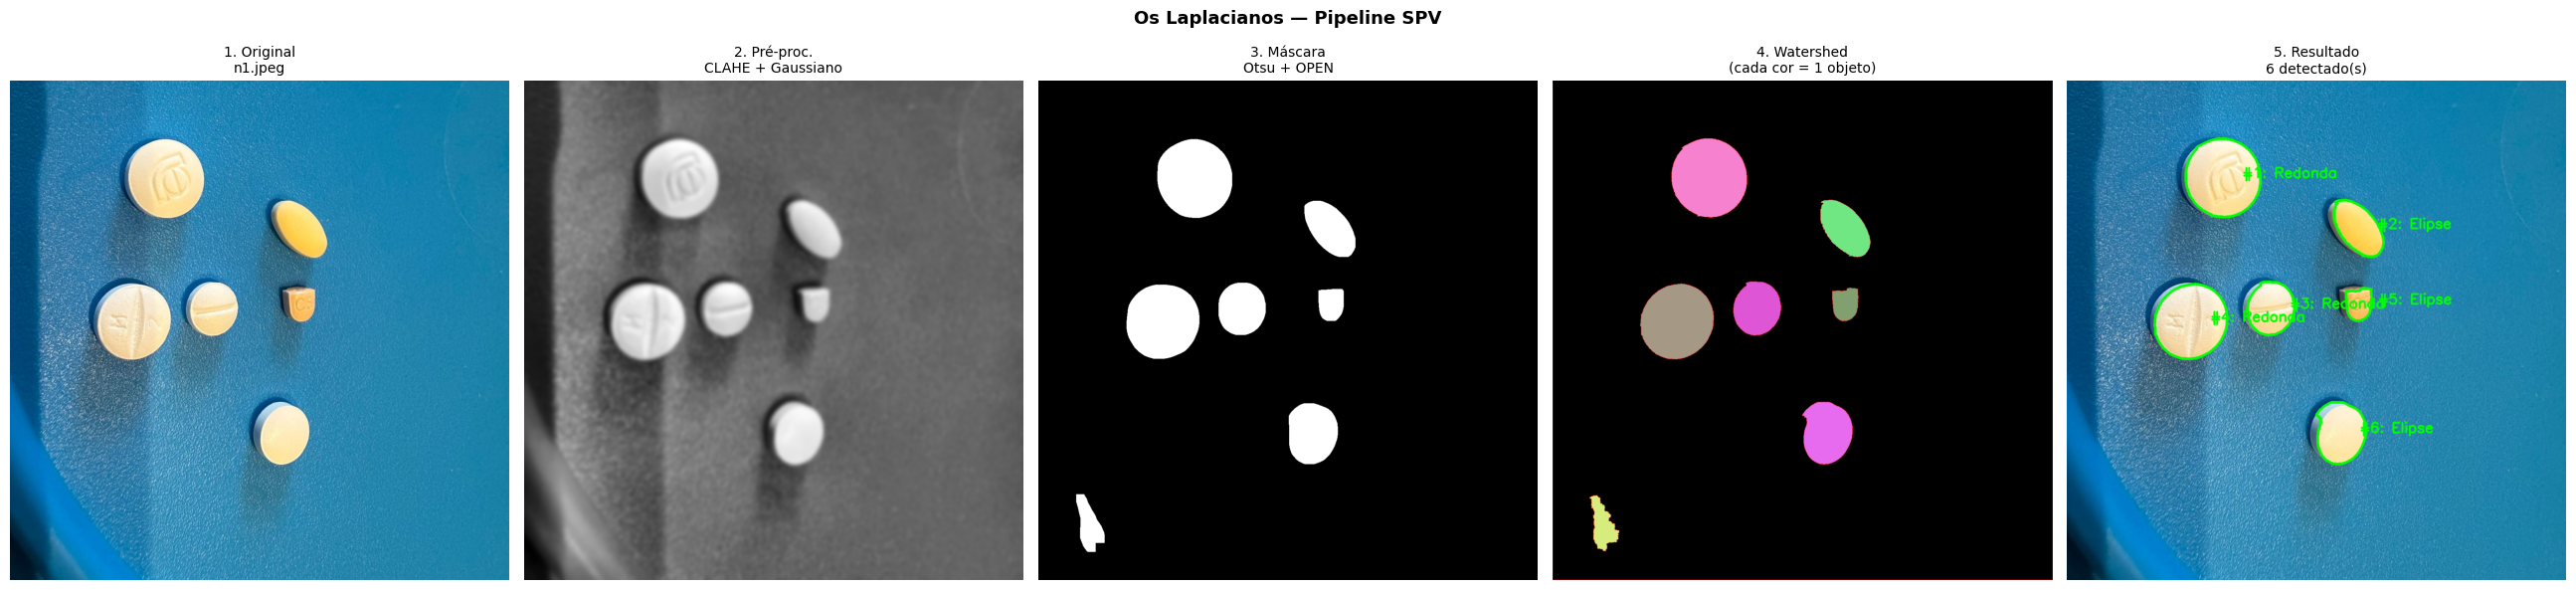

[n1.jpeg] Detectados: 6 | Esperados: 6 | Dose correta!


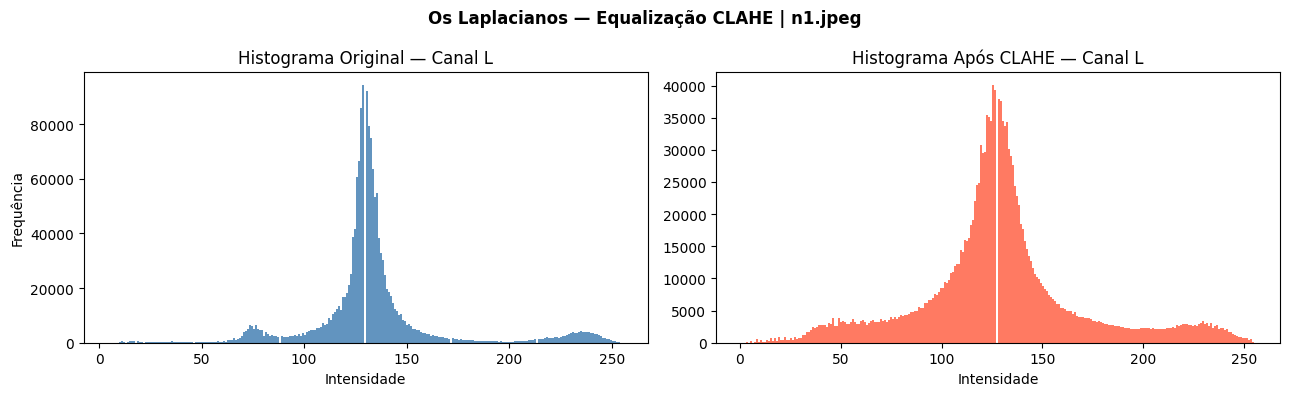

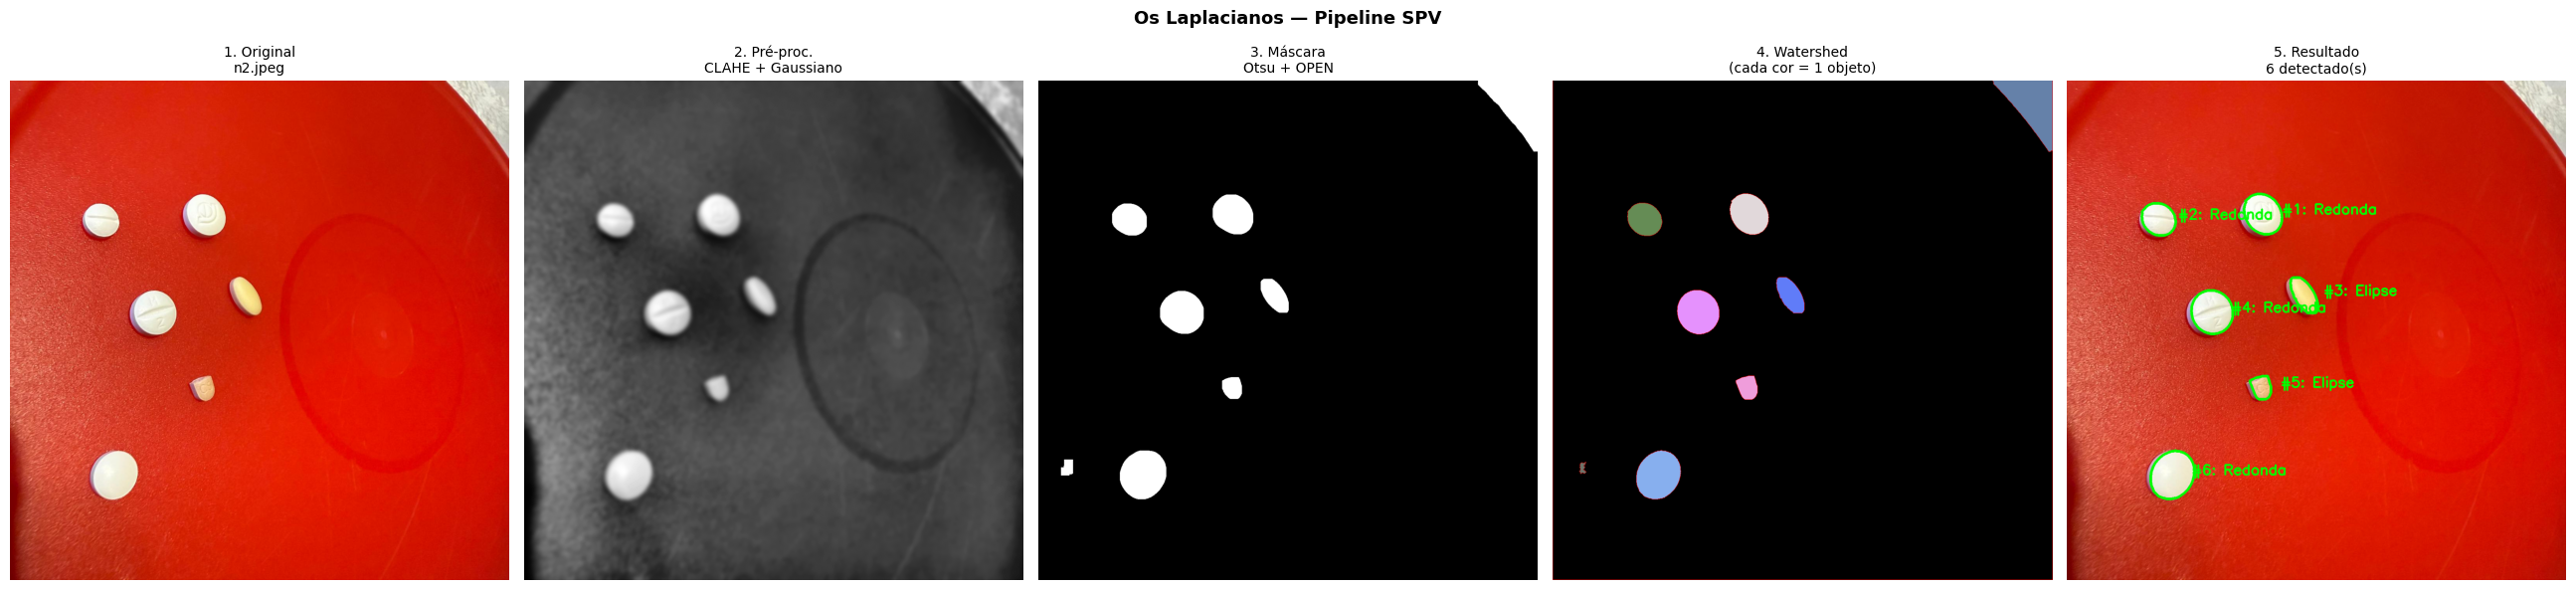

[n2.jpeg] Detectados: 6 | Esperados: 6 | Dose correta!


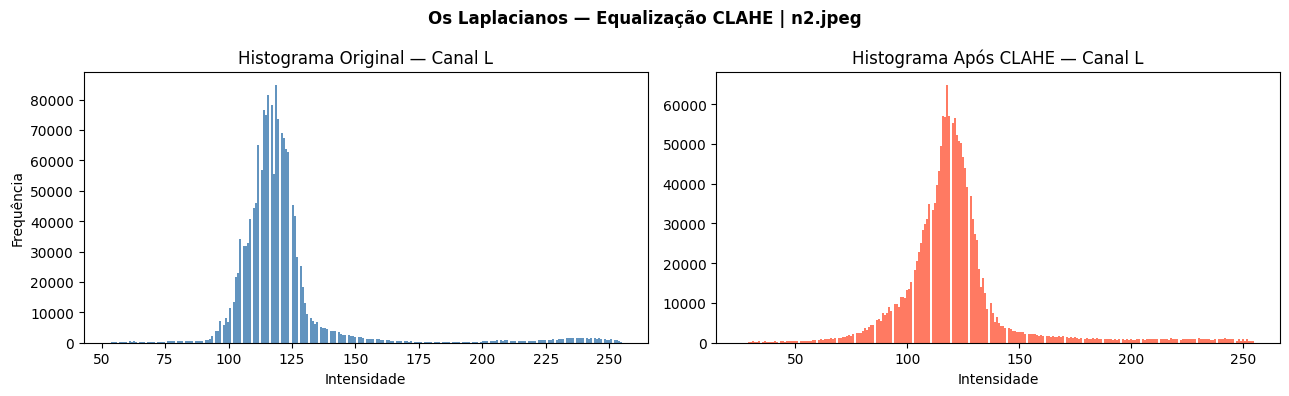

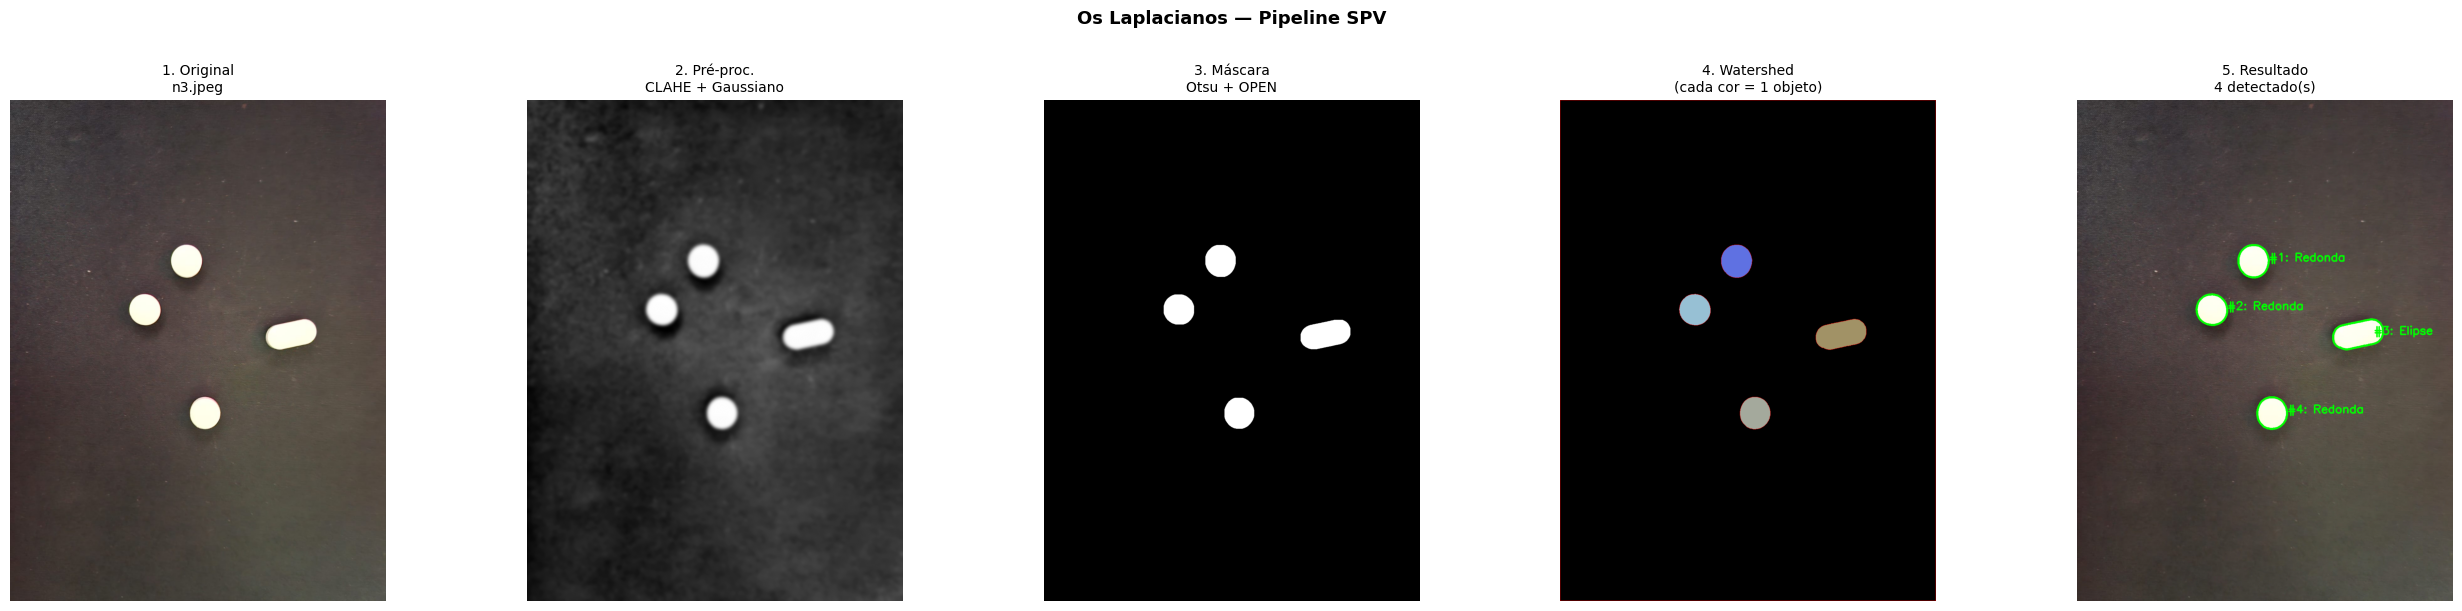

[n3.jpeg] Detectados: 4 | Esperados: 4 | Dose correta!


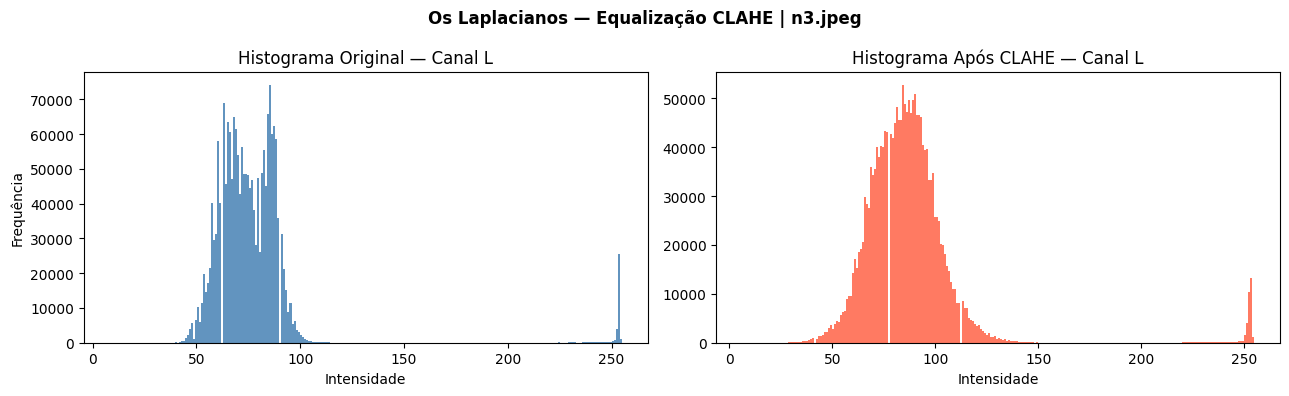

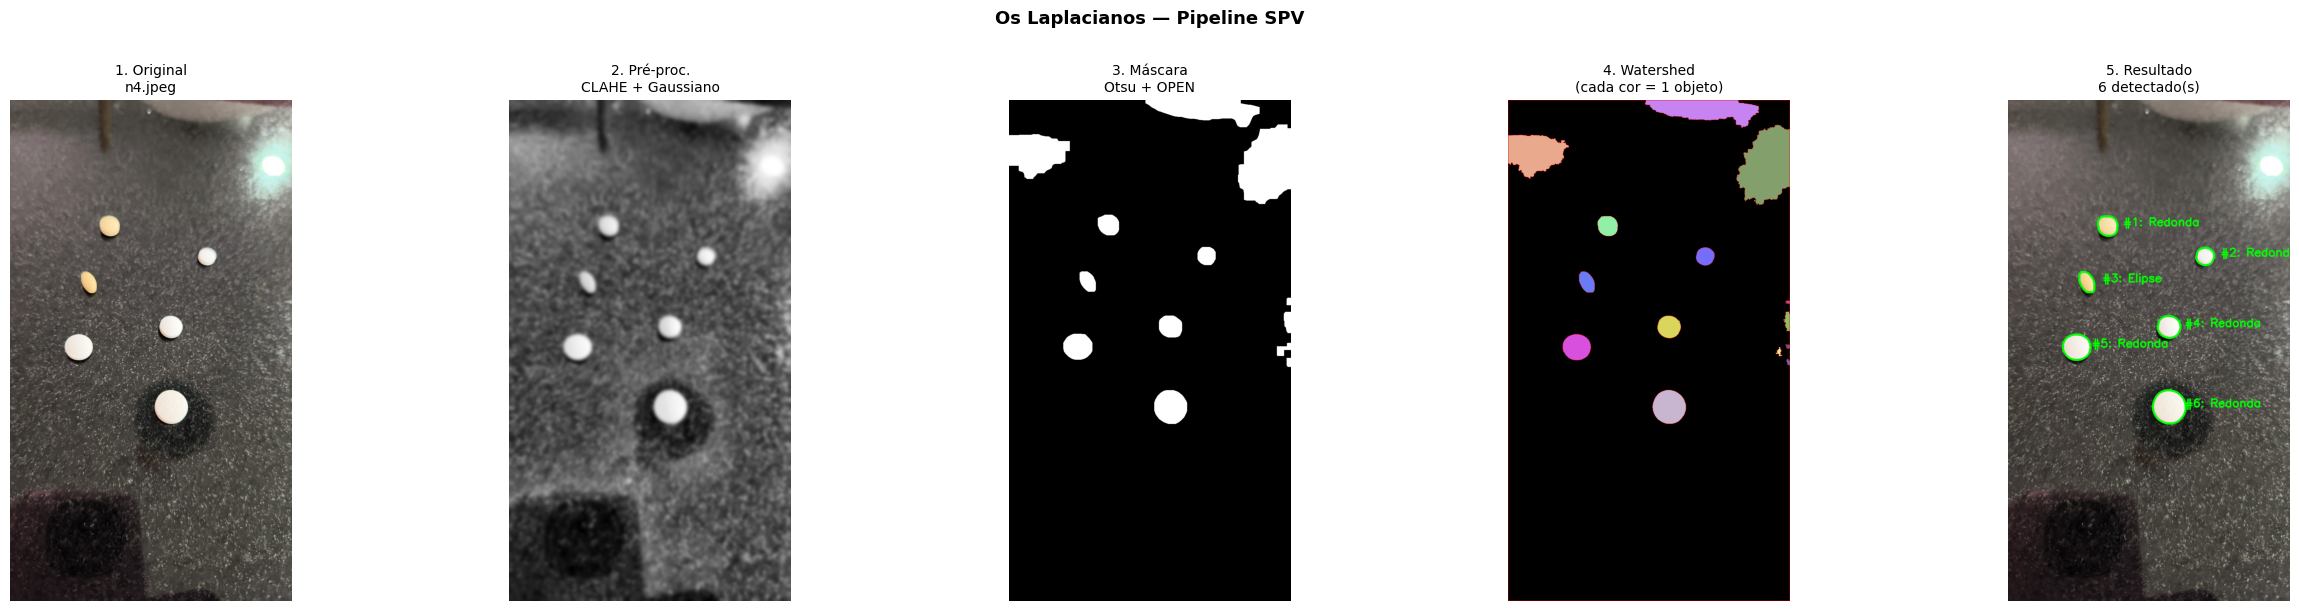

[n4.jpeg] Detectados: 6 | Esperados: 6 | Dose correta!


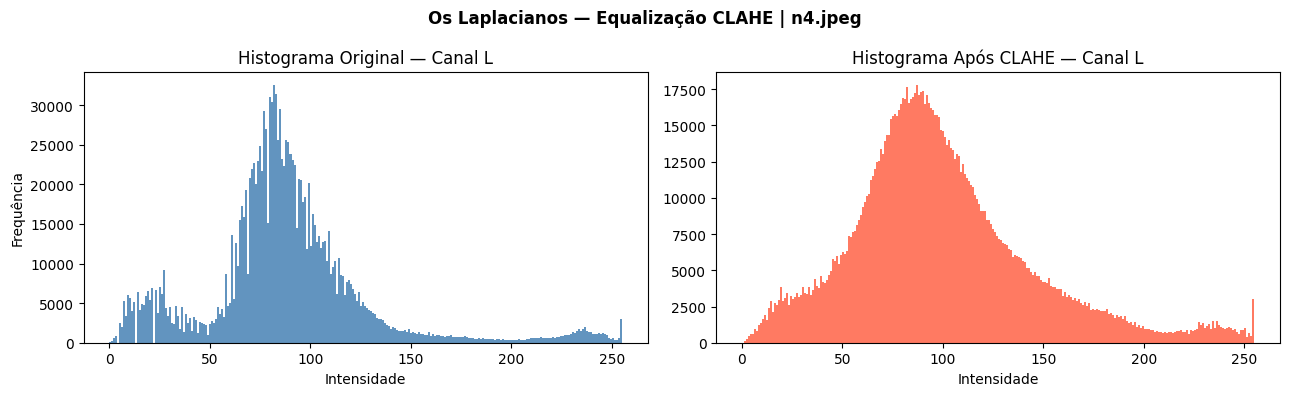

In [151]:
pasta = "images"
extensoes = ('.jpg', '.jpeg', '.png')

if os.path.exists(pasta):
    arquivos = sorted([f for f in os.listdir(pasta)
                       if f.lower().endswith(extensoes)])
    print(f"{len(arquivos)} imagem(ns) encontrada(s) em '{pasta}'\n")

    resultados = {}  # guarda contagens para análise posterior

    for arquivo in arquivos:
        caminho = os.path.join(pasta, arquivo)

        # Detecta n comprimidos na imagem
        n = exibir_deteccao_comprimidos(
          caminho,
          dose_esperada=ground_truth[arquivo]
        )

        # Histograma separado por imagem
        exibir_histograma(caminho)

        if n is not None:
            resultados[arquivo] = n
else:
    print(f"Pasta '{pasta}' não encontrada.")

## 7. Métricas de Desempenho

  Os Laplacianos — Métricas de Desempenho SPV
  Imagens avaliadas         : 4
  Erro Absoluto Médio (MAE) : 0.000
  Acurácia (contagem exata) : 100.0%

  [OK]  n1.jpeg                         detectado=6  real=6  erro=+0
  [OK]  n2.jpeg                         detectado=6  real=6  erro=+0
  [OK]  n3.jpeg                         detectado=4  real=4  erro=+0
  [OK]  n4.jpeg                         detectado=6  real=6  erro=+0


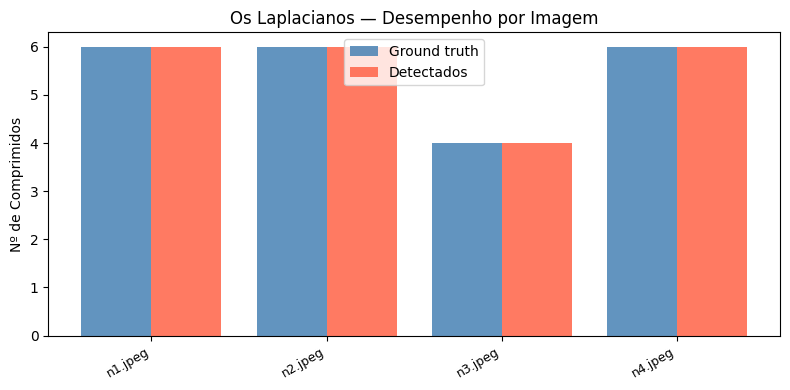

In [152]:
def calcular_metricas(resultados, ground_truth):
    """
    Calcula métricas objetivas de desempenho do SPV.

    Métricas:
        MAE      : Erro Absoluto Médio entre detectado e real
        Acurácia : % de imagens com contagem exata
    """
    comuns = [k for k in resultados if k in ground_truth]

    erros    = [abs(resultados[k] - ground_truth[k]) for k in comuns]
    acertos  = [resultados[k] == ground_truth[k]     for k in comuns]
    mae      = np.mean(erros)
    acuracia = np.mean(acertos) * 100

    print("=" * 54)
    print("  Os Laplacianos — Métricas de Desempenho SPV")
    print("=" * 54)
    print(f"  Imagens avaliadas         : {len(comuns)}")
    print(f"  Erro Absoluto Médio (MAE) : {mae:.3f}")
    print(f"  Acurácia (contagem exata) : {acuracia:.1f}%")
    print("=" * 54)
    print()

    for k in comuns:
        det, real = resultados[k], ground_truth[k]
        ok = "[OK]" if det == real else "[ERRO]"
        print(f"  {ok}  {k:<30s}  detectado={det}  real={real}  erro={det-real:+d}")

    # Gráfico comparativo
    x      = np.arange(len(comuns))
    det_v  = [resultados[k]    for k in comuns]
    real_v = [ground_truth[k]  for k in comuns]

    fig, ax = plt.subplots(figsize=(max(8, len(comuns) * 1.5), 4))
    ax.bar(x - 0.2, real_v, 0.4, label='Ground truth', color='steelblue', alpha=0.85)
    ax.bar(x + 0.2, det_v,  0.4, label='Detectados',   color='tomato',    alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(comuns, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel('Nº de Comprimidos')
    ax.set_title('Os Laplacianos — Desempenho por Imagem')
    ax.legend()
    plt.tight_layout()
    plt.show()


calcular_metricas(resultados, ground_truth)

## 8. Análise da Influência da Iluminação
Agrupando as imagens por condição de iluminação e compare o desempenho.

  Baixa     : MAE = 0.000
  Média     : MAE = 0.000
  Alta      : MAE = 0.000


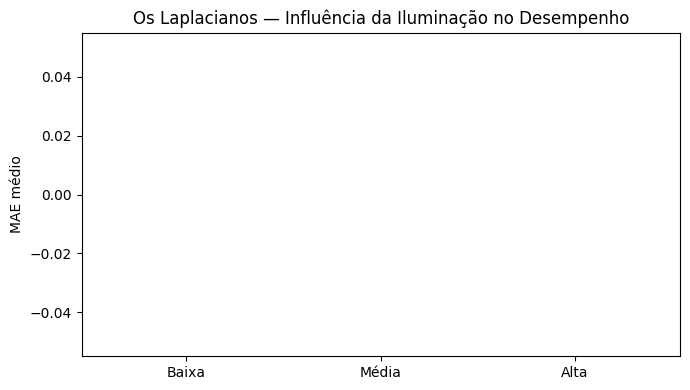

In [153]:
grupos_iluminacao = {
  'Baixa'  : ['n4.jpeg'],
  'Média'  : ['n3.jpeg'],
  'Alta'   : ['n1.jpeg', 'n2.jpeg'],
}

def analisar_iluminacao(resultados, ground_truth, grupos):
    """
    Calcula o MAE médio por grupo de iluminação e plota comparativo.
    """

    mae_por_grupo = {}
    for grupo, arquivos in grupos.items():
        erros = [abs(resultados.get(f, 0) - ground_truth.get(f, 0))
                 for f in arquivos if f in resultados and f in ground_truth]
        mae_por_grupo[grupo] = np.mean(erros) if erros else None
        print(f"  {grupo:10s}: MAE = {mae_por_grupo[grupo]:.3f}" if mae_por_grupo[grupo] is not None
              else f"  {grupo:10s}: sem dados de ground truth")

    grupos_validos = {k: v for k, v in mae_por_grupo.items() if v is not None}
    if grupos_validos:
        plt.figure(figsize=(7, 4))
        plt.bar(grupos_validos.keys(), grupos_validos.values(),
                color='steelblue', alpha=0.85)
        plt.ylabel('MAE médio')
        plt.title('Os Laplacianos — Influência da Iluminação no Desempenho')
        plt.tight_layout()
        plt.show()


analisar_iluminacao(resultados, ground_truth, grupos_iluminacao)